# 11. Dependence and causality comparison

This one-seed prototype compares lagged correlation, Granger-predictive evidence, and time-delayed mutual information (TDMI) in five synthetic cases.

**Frozen timing.** \(E_i \longrightarrow \omega_{i+1} \longrightarrow X_{i+1}\). Event age 0 maps to state-series lag +1, the exact direct model-imposed lag. Lags +1 through +13 are the direct response window; negative lags are reverse-direction diagnostics. Synthetic truth is not an estimator input.

## Load the frozen workflow

Notebook 06 supplies the simulator, observable transition table, common-shock bank, historical-GC convention, and binned TDMI estimator.

In [1]:
RUN_HELPER_SELF_TESTS = False
%run "./06_experiment_workflow_helpers.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

required = ['make_case_config', 'make_shock_bank', 'simulate_case', 'build_transition_table', 'derive_timing', 'compute_tdmi_curve', '_historical_gc', 'reference_config']
assert all(name in globals() for name in required)
print('Frozen Notebook 06 helpers loaded.')

Helper self-tests skipped for downstream use.
Frozen Notebook 06 helpers loaded.


## Registry and paired simulations

The cases reuse the frozen dense benchmark, Notebook 10 irregular calendar, Notebook 07 isolated state-dependent \(\nu\), and Notebook 09 local n=2 matching rule. All five receive the same fixed \(\epsilon_i\) and \(\eta_i\) shocks.

In [2]:
STEPS_PER_YEAR = 252
MARKET_SHOCK_SEED = 20260726
LAGS = list(range(-30, 31))
DIRECT_LAGS = list(range(1, 14))
IRREGULAR_STEPS = np.array([21, 52, 113, 134, 203, 249, 276, 302, 364, 396, 449, 483])


def nu_state_dependent(t, S, sigma, returns, params):
    """Notebook 07 clean state-dependent volatility-of-volatility function."""
    theta = float(params['theta'])
    z = (float(sigma) - theta) / max(theta, 1e-12)
    return float(params['nu_0'] * (1 + 0.5 * np.tanh(3 * z)))


dense = make_case_config(reference_config, label='dense_periodic_n1')
sparse = make_case_config(dense, {'events.period': 42 / STEPS_PER_YEAR}, label='sparse_irregular_n1')
nonlinear = make_case_config(reference_config, label='state_dependent_nu_n1')
n2_source = make_case_config(reference_config, {'model': reference_config['validation']['n2_model']}, label='n2_source')
sigma_ref = dense['simulation']['sigma0']
n2_matched = make_case_config(n2_source, {'model.theta': sigma_ref ** 2, 'model.nu_0': 2 * sigma_ref * dense['model']['nu_0'], 'model.rho_0': dense['model']['rho_0'], 'model.kappa': dense['model']['kappa'], 'simulation.sigma0': sigma_ref}, label='locally_scale_matched_n2')
no_effect = make_case_config(dense, {'events.amplitude': 0.0}, label='no_effect_n1')

plan = [
    ('Dense periodic (n=1)', dense, None, None, 'periodic every 21 steps', 'none', 'Main benchmark; periodicity and aliasing diagnostics.'),
    ('Sparse irregular (n=1)', sparse, IRREGULAR_STEPS / STEPS_PER_YEAR, None, 'irregular: 21, 52, 113, 134, 203, 249, 276, 302, 364, 396, 449, 483', 'none', 'Event-scarcity and irregular-calendar stress.'),
    ('State-dependent nu (n=1)', nonlinear, None, {'nu_fn': nu_state_dependent}, 'periodic every 21 steps', 'nu(sigma) only', 'Nonlinear background dynamics.'),
    ('Locally scale-matched (n=2)', n2_matched, None, None, 'periodic every 21 steps', 'Notebook 09 local n=2 match', 'Matched volatility/variance representation comparison.'),
    ('No effect (n=1)', no_effect, None, None, 'periodic every 21 steps', 'none; A=0', 'False-positive benchmark with the calendar retained.'),
]

registry, results, preflight = [], {}, []
shocks = make_shock_bank(dense, seed=MARKET_SHOCK_SEED)
reference_transitions = None
for name, config, schedule, functions, schedule_text, nonlinear_text, purpose in plan:
    timing = derive_timing(config)
    simpack = simulate_case(config, shock_bank=shocks, functions=functions, event_schedule=schedule, _timing=timing)
    sim = simpack['simulation']
    table, features = build_transition_table(sim, config, timing)
    transitions, states = sim['transitions'], sim['states']
    if reference_transitions is None:
        reference_transitions = transitions
    expected_count = len(IRREGULAR_STEPS) if schedule is not None else 23
    checks = {
        'simulation success': np.isfinite(states[['S', 'sigma', 'x']].to_numpy()).all() and np.isfinite(transitions[['F', 'x_next', 'sigma_next', 'omega_next']].to_numpy()).all(),
        'state positivity': states[['S', 'sigma', 'x']].gt(0).all().all() and transitions[['F', 'x_next', 'sigma_next', 'omega_next']].gt(0).all().all(),
        'expected event count': int(transitions.event.sum()) == expected_count,
        'event-to-state timing': (transitions.loc[transitions.event.eq(1), 'target_i'] == transitions.loc[transitions.event.eq(1), 'i'] + 1).all(),
        'response horizon': timing['response_horizon_steps'] == 12 and tuple(timing['event_transition_ages']) == tuple(range(13)),
        'no missing values': not table[['event_i', 'state_i', 'delta_state_next']].isna().any().any(),
        'common epsilon': np.array_equal(transitions.epsilon.to_numpy(), reference_transitions.epsilon.to_numpy()),
        'common eta': np.array_equal(transitions.eta.to_numpy(), reference_transitions.eta.to_numpy()),
    }
    assert all(checks.values()), (name, checks)
    results[name] = {'table': table, 'timing': timing}
    registry.append({'case name': name, 'n': config['model']['n'], 'nominal period (transitions)': timing['event_period_steps'], 'event schedule': schedule_text, 'event count': expected_count, 'amplitude': config['events']['amplitude'], 'decay': config['events']['decay_rate'], 'nonlinear specification': nonlinear_text, 'purpose': purpose})
    preflight.append({'case name': name, 'events': int(transitions.event.sum()), **checks})

case_registry = pd.DataFrame(registry)
preflight_table = pd.DataFrame(preflight)
display(case_registry)
display(preflight_table)
assert preflight_table.drop(columns=['case name', 'events']).all().all()

,case name,n,nominal period (transitions),event schedule,event count,amplitude,decay,nonlinear specification,purpose
0,Dense periodic (n=1),1,21,periodic every 21 steps,23,0.01,35.0,none,Main benchmark; periodicity and aliasing diagn...
1,Sparse irregular (n=1),1,42,"irregular: 21, 52, 113, 134, 203, 249, 276, 30...",12,0.01,35.0,none,Event-scarcity and irregular-calendar stress.
2,State-dependent nu (n=1),1,21,periodic every 21 steps,23,0.01,35.0,nu(sigma) only,Nonlinear background dynamics.
3,Locally scale-matched (n=2),2,21,periodic every 21 steps,23,0.01,35.0,Notebook 09 local n=2 match,Matched volatility/variance representation com...
4,No effect (n=1),1,21,periodic every 21 steps,23,0.00,35.0,none; A=0,False-positive benchmark with the calendar ret...


,case name,events,simulation success,state positivity,expected event count,event-to-state timing,response horizon,no missing values,common epsilon,common eta
0,Dense periodic (n=1),23,True,True,True,True,True,True,True,True
1,Sparse irregular (n=1),12,True,True,True,True,True,True,True,True
2,State-dependent nu (n=1),23,True,True,True,True,True,True,True,True
3,Locally scale-matched (n=2),23,True,True,True,True,True,True,True,True
4,No effect (n=1),23,True,True,True,True,True,True,True,True


## Lagged correlation

Pearson correlation is signed but non-directional association, not causality. Positive lag pairs an event with a later state observation, so +1 is the exact direct model-imposed lag.

,case name,transformation,correlation at +1,direct-window peak correlation,direct-window peak lag,exact +1 recovery,global peak correlation,global peak lag,global peak is negative,global peak outside direct window
0,Dense periodic (n=1),volatility-state levels,-0.024385,0.021414,7,False,0.026925,-10,True,True
1,Dense periodic (n=1),volatility-state changes,0.120165,0.155826,2,False,0.167779,23,False,True
2,Sparse irregular (n=1),volatility-state levels,-0.067258,0.040901,13,False,0.040901,13,False,False
3,Sparse irregular (n=1),volatility-state changes,0.152610,0.152610,1,True,0.152610,1,False,False
4,State-dependent nu (n=1),volatility-state levels,-0.023518,0.024391,7,False,0.030111,-14,True,True
5,State-dependent nu (n=1),volatility-state changes,0.088786,0.125863,2,False,0.135175,23,False,True
6,Locally scale-matched (n=2),volatility-state levels,-0.023851,0.017841,7,False,0.022838,-10,True,True
7,Locally scale-matched (n=2),volatility-state changes,0.153258,0.181937,2,False,0.194537,23,False,True
8,No effect (n=1),volatility-state levels,0.009602,0.009816,6,False,0.020807,-21,True,True
9,No effect (n=1),volatility-state changes,-0.069808,0.044081,11,False,0.064715,-24,True,True


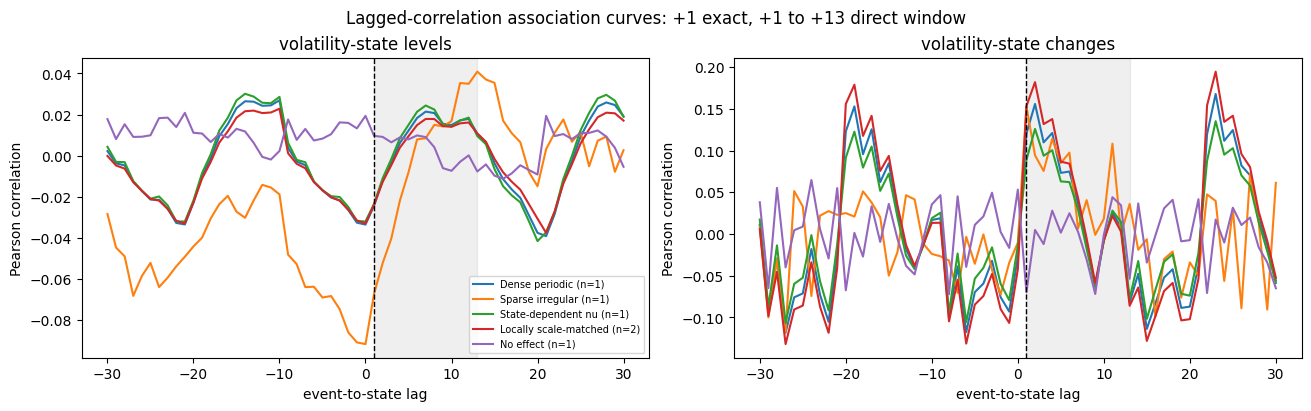

In [3]:
def lagged_curve(source, target, lags, column):
    """Use the same signed positive-lag alignment as Notebook 06 TDMI."""
    source, target = np.asarray(source, float), np.asarray(target, float)
    rows = []
    for lag in lags:
        x, y = (source[:-lag], target[lag:]) if lag > 0 else ((source[-lag:], target[:lag]) if lag < 0 else (source, target))
        value = np.corrcoef(x, y)[0, 1] if column == 'correlation' else None
        rows.append({'lag': lag, column: value, 'n_pairs': len(x)})
    return pd.DataFrame(rows)


def curve_summary(curve, column, label):
    direct_peak = curve.loc[curve.lag.isin(DIRECT_LAGS)].nlargest(1, column).iloc[0]
    global_peak = curve.loc[curve[column].idxmax()]
    return {
        label + ' at +1': float(curve.loc[curve.lag.eq(1), column].iloc[0]),
        'direct-window peak ' + label: float(direct_peak[column]),
        'direct-window peak lag': int(direct_peak.lag),
        'exact +1 recovery': bool(direct_peak.lag == 1),
        'global peak ' + label: float(global_peak[column]),
        'global peak lag': int(global_peak.lag),
        'global peak is negative': bool(global_peak.lag < 0),
        'global peak outside direct window': bool(global_peak.lag not in DIRECT_LAGS),
    }

corr_curves, corr_rows = {}, []
for case_name, result in results.items():
    event = result['table'].event_i.to_numpy()
    level = result['table'].state_i.to_numpy()
    for transformation, source, target in [('volatility-state levels', event, level), ('volatility-state changes', event[1:], np.diff(level))]:
        curve = lagged_curve(source, target, LAGS, 'correlation')
        corr_curves[(case_name, transformation)] = curve
        corr_rows.append({'case name': case_name, 'transformation': transformation, **curve_summary(curve, 'correlation', 'correlation')})
correlation_summary = pd.DataFrame(corr_rows)
display(correlation_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, constrained_layout=True)
for ax, transformation in zip(axes, ['volatility-state levels', 'volatility-state changes']):
    for case_name in results:
        curve = corr_curves[(case_name, transformation)]
        ax.plot(curve.lag, curve.correlation, label=case_name)
    ax.axvline(1, color='black', linestyle='--', linewidth=1)
    ax.axvspan(1, 13, color='grey', alpha=.12)
    ax.set(title=transformation, xlabel='event-to-state lag', ylabel='Pearson correlation')
axes[0].legend(fontsize=7)
fig.suptitle('Lagged-correlation association curves: +1 exact, +1 to +13 direct window')
plt.show()

## Granger-predictive evidence

Only p=1 and p=13 are tested using the frozen nested-autoregression convention. Reverse rejection is a reverse predictive diagnostic, not evidence that volatility physically causes scheduled events.

,case name,lag_order,direction,transformation,F_statistic,p_value,significant_5pct,partial_R_squared,sample_size
0,Dense periodic (n=1),1,event history -> volatility state,levels,6.806446,9.361632e-03,True,0.013756,491
1,Dense periodic (n=1),1,volatility-state history -> event,levels,0.578701,4.471894e-01,False,0.001184,491
2,Dense periodic (n=1),1,event history -> volatility-state change,changes,7.236696,7.388144e-03,True,0.014642,490
3,Dense periodic (n=1),1,volatility-state-change history -> event,changes,4.386928,3.673169e-02,True,0.008928,490
4,Dense periodic (n=1),13,event history -> volatility state,levels,4.457165,3.766745e-07,True,0.113627,479
5,Dense periodic (n=1),13,volatility-state history -> event,levels,1.307794,2.043220e-01,False,0.036250,479
6,Dense periodic (n=1),13,event history -> volatility-state change,changes,4.553859,2.392193e-07,True,0.116033,478
7,Dense periodic (n=1),13,volatility-state-change history -> event,changes,1.661366,6.624972e-02,False,0.045700,478
8,Sparse irregular (n=1),1,event history -> volatility state,levels,10.605897,1.205717e-03,True,0.021271,491
9,Sparse irregular (n=1),1,volatility-state history -> event,levels,4.332128,3.792019e-02,True,0.008799,491


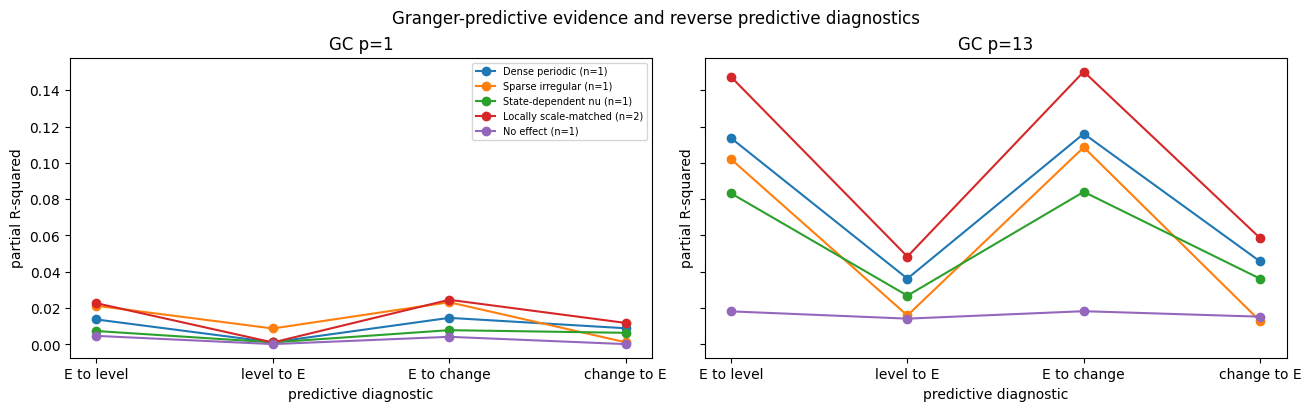

In [4]:
gc_rows = []
for case_name, result in results.items():
    event = result['table'].event_i.to_numpy(float)
    level = result['table'].state_i.to_numpy(float)
    change, event_for_change = np.diff(level), event[1:]
    diagnostics = [
        (level, event, 'event history -> volatility state', 'levels'),
        (event, level, 'volatility-state history -> event', 'levels'),
        (change, event_for_change, 'event history -> volatility-state change', 'changes'),
        (event_for_change, change, 'volatility-state-change history -> event', 'changes'),
    ]
    for order in [1, 13]:
        for target, driver, direction, transformation in diagnostics:
            row, metadata = _historical_gc(target, driver, order, transformation, transformation)
            row.update({'case name': case_name, 'direction': direction, 'transformation': transformation})
            gc_rows.append(row)

gc_results = pd.DataFrame(gc_rows)[['case name', 'lag_order', 'direction', 'transformation', 'F_statistic', 'p_value', 'significant_5pct', 'partial_R_squared', 'sample_size']]
display(gc_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True, constrained_layout=True)
for ax, order in zip(axes, [1, 13]):
    subset = gc_results.loc[gc_results.lag_order.eq(order)]
    labels = ['E to level', 'level to E', 'E to change', 'change to E']
    for case_name in results:
        ax.plot(labels, subset.loc[subset['case name'].eq(case_name), 'partial_R_squared'], marker='o', label=case_name)
    ax.set(title='GC p=' + str(order), xlabel='predictive diagnostic', ylabel='partial R-squared')
axes[0].legend(fontsize=7)
fig.suptitle('Granger-predictive evidence and reverse predictive diagnostics')
plt.show()

## TDMI

TDMI is lagged statistical dependence. The inherited Notebook 06 binned estimator is used unchanged on the signed -30 to +30 grid; its largest peak is not automatically treated as the true causal lag.

,case name,transformation,TDMI at +1,direct-window peak TDMI,direct-window peak lag,exact +1 recovery,global peak TDMI,global peak lag,global peak is negative,global peak outside direct window
0,Dense periodic (n=1),volatility-state levels,0.011016,0.011016,1,True,0.014537,19,False,True
1,Dense periodic (n=1),volatility-state changes,0.024186,0.024186,1,True,0.024186,1,False,False
2,Sparse irregular (n=1),volatility-state levels,0.007007,0.016871,5,False,0.020201,-6,True,True
3,Sparse irregular (n=1),volatility-state changes,0.009194,0.024342,11,False,0.024342,11,False,False
4,State-dependent nu (n=1),volatility-state levels,0.008611,0.012112,6,False,0.012664,27,False,True
5,State-dependent nu (n=1),volatility-state changes,0.032048,0.032048,1,True,0.032048,1,False,False
6,Locally scale-matched (n=2),volatility-state levels,0.009907,0.010581,11,False,0.010581,11,False,False
7,Locally scale-matched (n=2),volatility-state changes,0.027058,0.027058,1,True,0.029032,22,False,True
8,No effect (n=1),volatility-state levels,0.003814,0.011197,4,False,0.012556,25,False,True
9,No effect (n=1),volatility-state changes,0.018613,0.022656,5,False,0.026780,-16,True,True


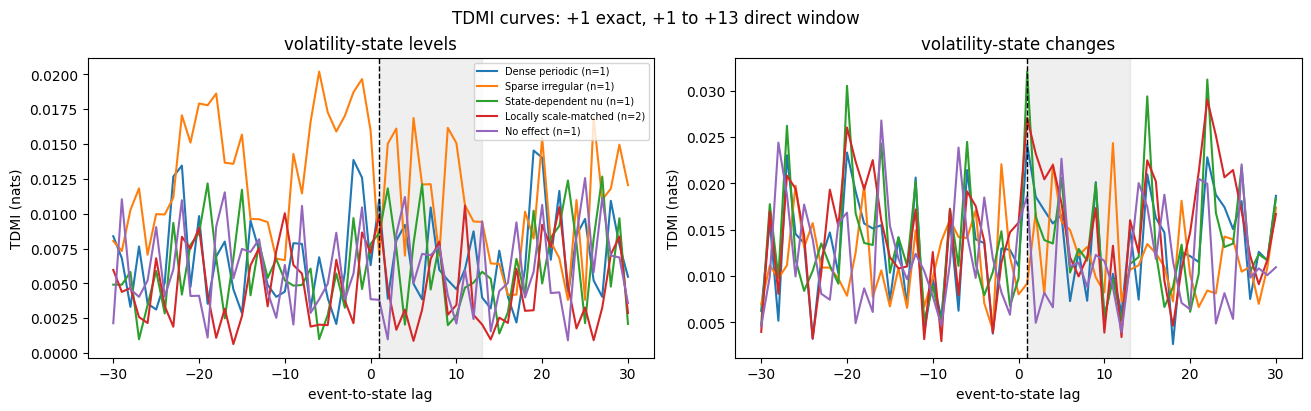

In [5]:
tdmi_curves, tdmi_rows = {}, []
for case_name, result in results.items():
    event = result['table'].event_i.to_numpy()
    level = result['table'].state_i.to_numpy()
    for transformation, source, target in [('volatility-state levels', event, level), ('volatility-state changes', event[1:], np.diff(level))]:
        curve = compute_tdmi_curve(source, target, LAGS, source_name='event_i', target_name=transformation, alignment='positive lag: event precedes later state')
        tdmi_curves[(case_name, transformation)] = curve
        tdmi_rows.append({'case name': case_name, 'transformation': transformation, **curve_summary(curve, 'mutual_information', 'TDMI')})
tdmi_summary = pd.DataFrame(tdmi_rows)
display(tdmi_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, constrained_layout=True)
for ax, transformation in zip(axes, ['volatility-state levels', 'volatility-state changes']):
    for case_name in results:
        curve = tdmi_curves[(case_name, transformation)]
        ax.plot(curve.lag, curve.mutual_information, label=case_name)
    ax.axvline(1, color='black', linestyle='--', linewidth=1)
    ax.axvspan(1, 13, color='grey', alpha=.12)
    ax.set(title=transformation, xlabel='event-to-state lag', ylabel='TDMI (nats)')
axes[0].legend(fontsize=7)
fig.suptitle('TDMI curves: +1 exact, +1 to +13 direct window')
plt.show()

## Prototype comparison

GC orders are predictive-history windows, not unique direct model-imposed-lag estimates: p=1 is GC predictive evidence at the pre-specified +1 lag, while p=13 is a joint direct-window predictive test. The table keeps methods separate and retains warnings instead of forming an arbitrary causality score.

In [6]:
comparison_rows = []
for case_name in results:
    for transformation in ['volatility-state levels', 'volatility-state changes']:
        corr = correlation_summary.loc[(correlation_summary['case name'].eq(case_name)) & (correlation_summary.transformation.eq(transformation))].iloc[0]
        tdmi = tdmi_summary.loc[(tdmi_summary['case name'].eq(case_name)) & (tdmi_summary.transformation.eq(transformation))].iloc[0]
        comparison_rows.append({
            'case name': case_name, 'method': 'Lagged correlation', 'transformation': transformation,
            'prototype evidence': 'descriptive only; significance not assessed',
            'forward versus reverse result': 'association only',
            'direct-window peak lag': corr['direct-window peak lag'], 'global peak lag': corr['global peak lag'],
            'exact +1 evidence': corr['exact +1 recovery'],
            'direct-window evidence': 'descriptive direct-window peak',
            'unique lag identified': False,
            'warning / interpretation note': 'Association is not causality.',
        })
        comparison_rows.append({
            'case name': case_name, 'method': 'TDMI', 'transformation': transformation,
            'prototype evidence': 'descriptive only; significance not assessed',
            'forward versus reverse result': 'signed-lag dependence; inspect global and direct peaks',
            'direct-window peak lag': tdmi['direct-window peak lag'], 'global peak lag': tdmi['global peak lag'],
            'exact +1 evidence': tdmi['exact +1 recovery'],
            'direct-window evidence': 'descriptive direct-window peak',
            'unique lag identified': False,
            'warning / interpretation note': 'Raw TDMI is not a significance claim; surrogate testing is deferred.',
        })
        gc_transformation = 'levels' if transformation.endswith('levels') else 'changes'
        for order in [1, 13]:
            forward = gc_results.loc[(gc_results['case name'].eq(case_name)) & (gc_results.lag_order.eq(order)) & (gc_results.direction.str.startswith('event history')) & (gc_results.transformation.eq(gc_transformation))].iloc[0]
            reverse = gc_results.loc[(gc_results['case name'].eq(case_name)) & (gc_results.lag_order.eq(order)) & (~gc_results.direction.str.startswith('event history')) & (gc_results.transformation.eq(gc_transformation))].iloc[0]
            if order == 1:
                exact_evidence = bool(forward.significant_5pct)
                direct_evidence = bool(forward.significant_5pct)
                unique_lag = 'p=1 forward predictive test; direct model-imposed lag not established'
            else:
                exact_evidence = 'not assessed by joint p=13 test'
                direct_evidence = bool(forward.significant_5pct)
                unique_lag = 'joint direct-window test; unique lag not identified'
            comparison_rows.append({
                'case name': case_name, 'method': 'Granger causality p=' + str(order), 'transformation': transformation,
                'prototype evidence': 'formal F-test at 5%',
                'forward versus reverse result': 'forward reject=' + str(bool(forward.significant_5pct)) + '; reverse predictive diagnostic reject=' + str(bool(reverse.significant_5pct)),
                'direct-window peak lag': np.nan, 'global peak lag': np.nan,
                'exact +1 evidence': exact_evidence, 'direct-window evidence': direct_evidence,
                'unique lag identified': unique_lag,
                'warning / interpretation note': 'Granger-predictive evidence only; no physical state-to-event causation claim.',
            })
prototype_comparison = pd.DataFrame(comparison_rows)
display(prototype_comparison)

def gc_rejection(case_name, order, direction_prefix, transformation):
    row = gc_results.loc[(gc_results['case name'].eq(case_name)) & (gc_results.lag_order.eq(order)) & (gc_results.direction.str.startswith(direction_prefix)) & (gc_results.transformation.eq(transformation))].iloc[0]
    return bool(row.significant_5pct)


def rejection_word(value):
    return 'rejects' if value else 'does not reject'


reverse_sentences = []
for case_name in results:
    p1_level = gc_rejection(case_name, 1, 'volatility-state history', 'levels')
    p1_change = gc_rejection(case_name, 1, 'volatility-state-change history', 'changes')
    p13_level = gc_rejection(case_name, 13, 'volatility-state history', 'levels')
    p13_change = gc_rejection(case_name, 13, 'volatility-state-change history', 'changes')
    reverse_sentences.append(case_name + ': p=1 reverse levels ' + rejection_word(p1_level) + ', changes ' + rejection_word(p1_change) + '; p=13 reverse levels ' + rejection_word(p13_level) + ', changes ' + rejection_word(p13_change) + '.')

change_exact = int(correlation_summary.loc[correlation_summary.transformation.eq('volatility-state changes'), 'exact +1 recovery'].sum())
level_exact = int(correlation_summary.loc[correlation_summary.transformation.eq('volatility-state levels'), 'exact +1 recovery'].sum())
tdmi_change_exact = int(tdmi_summary.loc[tdmi_summary.transformation.eq('volatility-state changes'), 'exact +1 recovery'].sum())
tdmi_level_exact = int(tdmi_summary.loc[tdmi_summary.transformation.eq('volatility-state levels'), 'exact +1 recovery'].sum())
no_effect_gc = gc_results.loc[gc_results['case name'].eq('No effect (n=1)')]
assert not no_effect_gc.significant_5pct.any()
conclusion_markdown = '## Conclusions\n\n'
conclusion_markdown += 'This is a one-seed prototype. Exact +1 recovery is stricter than descriptive dependence: correlation recovers +1 in ' + str(change_exact) + ' of 5 change rows and ' + str(level_exact) + ' of 5 level rows, while TDMI recovers +1 in ' + str(tdmi_change_exact) + ' of 5 change rows and ' + str(tdmi_level_exact) + ' of 5 level rows. Changes are therefore more often aligned with +1 here, but neither descriptive diagnostic recovers it uniformly.\n\n'
conclusion_markdown += 'Reverse predictive diagnostics from the executed GC table are: ' + ' '.join(reverse_sentences) + ' Reverse rejection is not physical volatility-to-event causation.\n\n'
conclusion_markdown += 'The no-effect case has no forward or reverse GC rejection, while its correlation and TDMI rows remain descriptive only because significance has not been assessed. Granger-predictive evidence, correlation association, and TDMI lagged statistical dependence remain observational diagnostics; none establishes interventionist or physical causality.'
display(Markdown(conclusion_markdown))

,case name,method,transformation,prototype evidence,forward versus reverse result,direct-window peak lag,global peak lag,exact +1 evidence,direct-window evidence,unique lag identified,warning / interpretation note
0,Dense periodic (n=1),Lagged correlation,volatility-state levels,descriptive only; significance not assessed,association only,7.0,-10.0,False,descriptive direct-window peak,False,Association is not causality.
1,Dense periodic (n=1),TDMI,volatility-state levels,descriptive only; significance not assessed,signed-lag dependence; inspect global and dire...,1.0,19.0,True,descriptive direct-window peak,False,Raw TDMI is not a significance claim; surrogat...
2,Dense periodic (n=1),Granger causality p=1,volatility-state levels,formal F-test at 5%,forward reject=True; reverse predictive diagno...,NaN,NaN,True,True,p=1 forward predictive test; direct model-impo...,Granger-predictive evidence only; no physical ...
3,Dense periodic (n=1),Granger causality p=13,volatility-state levels,formal F-test at 5%,forward reject=True; reverse predictive diagno...,NaN,NaN,not assessed by joint p=13 test,True,joint direct-window test; unique lag not ident...,Granger-predictive evidence only; no physical ...
4,Dense periodic (n=1),Lagged correlation,volatility-state changes,descriptive only; significance not assessed,association only,2.0,23.0,False,descriptive direct-window peak,False,Association is not causality.
5,Dense periodic (n=1),TDMI,volatility-state changes,descriptive only; significance not assessed,signed-lag dependence; inspect global and dire...,1.0,1.0,True,descriptive direct-window peak,False,Raw TDMI is not a significance claim; surrogat...
6,Dense periodic (n=1),Granger causality p=1,volatility-state changes,formal F-test at 5%,forward reject=True; reverse predictive diagno...,NaN,NaN,True,True,p=1 forward predictive test; direct model-impo...,Granger-predictive evidence only; no physical ...
7,Dense periodic (n=1),Granger causality p=13,volatility-state changes,formal F-test at 5%,forward reject=True; reverse predictive diagno...,NaN,NaN,not assessed by joint p=13 test,True,joint direct-window test; unique lag not ident...,Granger-predictive evidence only; no physical ...
8,Sparse irregular (n=1),Lagged correlation,volatility-state levels,descriptive only; significance not assessed,association only,13.0,13.0,False,descriptive direct-window peak,False,Association is not causality.
9,Sparse irregular (n=1),TDMI,volatility-state levels,descriptive only; significance not assessed,signed-lag dependence; inspect global and dire...,5.0,-6.0,False,descriptive direct-window peak,False,Raw TDMI is not a significance claim; surrogat...


## Conclusions

This is a one-seed prototype. Exact +1 recovery is stricter than descriptive dependence: correlation recovers +1 in 1 of 5 change rows and 0 of 5 level rows, while TDMI recovers +1 in 3 of 5 change rows and 1 of 5 level rows. Changes are therefore more often aligned with +1 here, but neither descriptive diagnostic recovers it uniformly.

Reverse predictive diagnostics from the executed GC table are: Dense periodic (n=1): p=1 reverse levels does not reject, changes rejects; p=13 reverse levels does not reject, changes does not reject. Sparse irregular (n=1): p=1 reverse levels rejects, changes does not reject; p=13 reverse levels does not reject, changes does not reject. State-dependent nu (n=1): p=1 reverse levels does not reject, changes does not reject; p=13 reverse levels does not reject, changes does not reject. Locally scale-matched (n=2): p=1 reverse levels does not reject, changes rejects; p=13 reverse levels rejects, changes rejects. No effect (n=1): p=1 reverse levels does not reject, changes does not reject; p=13 reverse levels does not reject, changes does not reject. Reverse rejection is not physical volatility-to-event causation.

The no-effect case has no forward or reverse GC rejection, while its correlation and TDMI rows remain descriptive only because significance has not been assessed. Granger-predictive evidence, correlation association, and TDMI lagged statistical dependence remain observational diagnostics; none establishes interventionist or physical causality.

## Final repeated experiment

The remaining cells validate one minimal transfer-entropy estimator, execute or load a paired 50-seed comparison, and report compact empirical summaries. No forecasting or additional model cases are introduced.

## Transfer-entropy estimator and validation

A single discrete conditional-mutual-information estimator uses four equal-frequency bins, natural logarithms, and one-step target-history conditioning while scanning the source lag. It is therefore reported precisely as a lag-specific conditional information-transfer / TE-style statistic, not as an estimate of every possible high-order transfer-entropy embedding. Validation is fixed before event-volatility analysis; TE enters the repeated comparison only when its predeclared gate passes.

In [7]:
N_TE_BINS = 4
TE_LAGS = list(range(1, 31))
N_TE_VALIDATION_SEEDS = 30
N_TE_VALIDATION_SURROGATES = 99
TE_VALIDATION_ALPHA = 0.05


def equal_frequency_codes(values, bins=N_TE_BINS):
    series = pd.Series(np.asarray(values, float))
    codes = pd.qcut(series, q=bins, labels=False, duplicates='drop')
    return pd.Series(codes).fillna(0).astype(int).to_numpy()


def discrete_cmi(target, source, condition):
    target = np.asarray(target, int)
    source = np.asarray(source, int)
    condition = np.asarray(condition, int)
    n_target = int(target.max()) + 1
    n_source = int(source.max()) + 1
    n_condition = int(condition.max()) + 1
    flat = (target * n_source + source) * n_condition + condition
    counts = np.bincount(flat, minlength=n_target * n_source * n_condition).reshape(n_target, n_source, n_condition)
    p_xyz = counts / counts.sum()
    p_yz = p_xyz.sum(axis=1, keepdims=True)
    p_xz = p_xyz.sum(axis=0, keepdims=True)
    p_z = p_xyz.sum(axis=(0, 1), keepdims=True)
    denominator = p_yz * p_xz
    p_z_broadcast = np.broadcast_to(p_z, p_xyz.shape)
    mask = (p_xyz > 0) & (p_z_broadcast > 0) & (denominator > 0)
    ratio = p_xyz[mask] * p_z_broadcast[mask] / denominator[mask]
    return float((p_xyz[mask] * np.log(ratio)).sum())


def transfer_entropy_codes(source_codes, target_codes, lag=1):
    return discrete_cmi(target_codes[lag:], source_codes[:-lag], target_codes[lag - 1:-1])


def transfer_entropy(source, target, lag=1, source_binary=False, target_binary=False):
    source_codes = np.asarray(source, int) if source_binary else equal_frequency_codes(source)
    target_codes = np.asarray(target, int) if target_binary else equal_frequency_codes(target)
    return transfer_entropy_codes(source_codes, target_codes, lag)


def forward_te_curve(event, state, lags=TE_LAGS):
    state_codes = equal_frequency_codes(state)
    return pd.DataFrame({'lag': list(lags), 'transfer_entropy': [transfer_entropy_codes(np.asarray(event, int), state_codes, lag) for lag in lags]})


def reverse_te_curve(event, state, lags=TE_LAGS):
    state_codes = equal_frequency_codes(state)
    return pd.DataFrame({'lag': list(lags), 'transfer_entropy': [transfer_entropy_codes(state_codes, np.asarray(event, int), lag) for lag in lags]})


def surrogate_te_p_value(source, target, rng):
    source_codes = equal_frequency_codes(source)
    target_codes = equal_frequency_codes(target)
    observed = transfer_entropy_codes(source_codes, target_codes, 1)
    surrogate_values = []
    for _ in range(N_TE_VALIDATION_SURROGATES):
        shift = int(rng.integers(1, len(source)))
        surrogate_values.append(transfer_entropy_codes(np.roll(source_codes, shift), target_codes, 1))
    p_value = (1 + np.sum(np.asarray(surrogate_values) >= observed)) / (1 + N_TE_VALIDATION_SURROGATES)
    return observed, float(p_value)


def validation_system(system, seed, length=600):
    rng = np.random.default_rng(seed)
    x = np.zeros(length)
    y = np.zeros(length)
    a, c = 0.60, 0.45
    for t in range(1, length):
        x[t] = a * x[t - 1] + rng.normal()
        if system == 'linear Gaussian direction':
            y[t] = c * y[t - 1] + 0.90 * x[t - 1] + rng.normal(scale=0.55)
        elif system == 'nonlinear direction':
            y[t] = c * y[t - 1] + 0.90 * (x[t - 1] ** 2 - 1 / (1 - a ** 2)) + rng.normal(scale=0.55)
        else:
            y[t] = c * y[t - 1] + rng.normal()
    return x, y


validation_rows = []
for system_index, system in enumerate(['linear Gaussian direction', 'nonlinear direction', 'independent persistent null']):
    for seed in range(N_TE_VALIDATION_SEEDS):
        x, y = validation_system(system, 8100 + 100 * system_index + seed)
        rng = np.random.default_rng(9100 + 100 * system_index + seed)
        forward_te, forward_p = surrogate_te_p_value(x, y, rng)
        reverse_te, reverse_p = surrogate_te_p_value(y, x, rng)
        validation_rows.extend([
            {'system': system, 'direction': 'forward', 'seed': seed, 'TE at +1': forward_te, 'p_value': forward_p, 'reject': forward_p <= TE_VALIDATION_ALPHA},
            {'system': system, 'direction': 'reverse', 'seed': seed, 'TE at +1': reverse_te, 'p_value': reverse_p, 'reject': reverse_p <= TE_VALIDATION_ALPHA},
        ])

te_validation_runs = pd.DataFrame(validation_rows)
validation_criteria = {
    ('linear Gaussian direction', 'forward'): 'rejection rate at least 70%',
    ('linear Gaussian direction', 'reverse'): 'rejection rate at most 25%',
    ('nonlinear direction', 'forward'): 'rejection rate at least 60%',
    ('nonlinear direction', 'reverse'): 'rejection rate at most 25%',
    ('independent persistent null', 'forward'): 'rejection rate at most 15%',
    ('independent persistent null', 'reverse'): 'rejection rate at most 15%',
}
validation_summary_rows = []
for (system, direction), group in te_validation_runs.groupby(['system', 'direction']):
    rate = float(group.reject.mean())
    lower_bound = system in ['linear Gaussian direction', 'nonlinear direction'] and direction == 'forward'
    passed = rate >= (0.70 if system == 'linear Gaussian direction' else 0.60) if lower_bound else rate <= (0.25 if system != 'independent persistent null' else 0.15)
    validation_summary_rows.append({'system': system, 'direction': direction, 'rejection rate': rate, 'median TE': float(group['TE at +1'].median()), 'required criterion': validation_criteria[(system, direction)], 'pass': bool(passed)})
te_validation = pd.DataFrame(validation_summary_rows)
TE_VALIDATION_PASSED = bool(te_validation['pass'].all())
display(te_validation)
print('TE_VALIDATION_PASSED =', TE_VALIDATION_PASSED)

,system,direction,rejection rate,median TE,required criterion,pass
0,independent persistent null,forward,0.066667,0.029201,rejection rate at most 15%,True
1,independent persistent null,reverse,0.066667,0.033401,rejection rate at most 15%,True
2,linear Gaussian direction,forward,1.000000,0.401070,rejection rate at least 70%,True
3,linear Gaussian direction,reverse,0.066667,0.032689,rejection rate at most 25%,True
4,nonlinear direction,forward,1.000000,0.297378,rejection rate at least 60%,True
5,nonlinear direction,reverse,0.000000,0.029636,rejection rate at most 25%,True


TE_VALIDATION_PASSED = True


## Paired repeated experiment and checkpoints

The existing 50-seed signal experiment is retained. A dedicated, checkpointed no-effect experiment uses 250 calibration seeds and a disjoint 250-seed held-out evaluation set. Correlation (signed but non-directional), TDMI (non-negative and non-directional), and the lag-specific conditional information-transfer / TE-style statistic retain their maximum-over-lags calibration; GC retains its parametric predictive tests.

In [8]:
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter
import json

N_REPEATED_SEEDS = 50
REPEATED_SEEDS = list(range(20260726, 20260726 + N_REPEATED_SEEDS))
REUSE_SIGNAL_CHECKPOINT = True
RESULTS_DIR_11 = Path('notebook11_results')
RESULTS_DIR_11.mkdir(exist_ok=True)
CONFIG_PATH = RESULTS_DIR_11 / 'experiment_config.json'
VALIDATION_PATH = RESULTS_DIR_11 / 'te_validation.csv'
METRICS_PATH = RESULTS_DIR_11 / 'run_metrics.csv'
CURVES_PATH = RESULTS_DIR_11 / 'lag_curves.csv'
FAILURES_PATH = RESULTS_DIR_11 / 'failures.csv'
MANIFEST_PATH = RESULTS_DIR_11 / 'manifest.json'


def largest_peak(curve, value_column, lags, absolute=False):
    subset = curve.loc[curve.lag.isin(list(lags))].copy()
    selector = subset[value_column].abs().idxmax() if absolute else subset[value_column].idxmax()
    row = subset.loc[selector]
    return float(abs(row[value_column]) if absolute else row[value_column]), int(row.lag)


def make_empirical_row(case_name, seed, method, transformation, forward_curve, reverse_curve, value_column, absolute=False):
    forward_stat, forward_global_lag = largest_peak(forward_curve, value_column, range(1, 31), absolute)
    reverse_stat, reverse_global_lag = largest_peak(reverse_curve, value_column, range(-30, 0), absolute)
    direct_stat, direct_lag = largest_peak(forward_curve, value_column, DIRECT_LAGS, absolute)
    return {
        'case_name': case_name, 'seed': seed, 'method': method, 'transformation': transformation,
        'forward_statistic': forward_stat, 'reverse_statistic': reverse_stat,
        'forward_threshold_or_pvalue': np.nan, 'reverse_threshold_or_pvalue': np.nan,
        'forward_detected': np.nan, 'reverse_detected': np.nan, 'directional_classification': '',
        'direct_window_peak_lag': direct_lag, 'global_peak_lag': forward_global_lag,
        'exact_plus_1_recovery': direct_lag == 1, 'direct_window_recovery': forward_global_lag in DIRECT_LAGS,
        'outside_direct_window_peak': forward_global_lag not in DIRECT_LAGS,
        'runtime_seconds': np.nan, 'warning_status': '',
    }


def run_seed_case(case_name, config, schedule, functions, seed, shock_bank):
    started = perf_counter()
    timing = derive_timing(config)
    simulation = simulate_case(config, shock_bank=shock_bank, functions=functions, event_schedule=schedule, _timing=timing)['simulation']
    table, features = build_transition_table(simulation, config, timing)
    transitions = simulation['transitions']
    assert np.array_equal(transitions.epsilon.to_numpy(), np.asarray(shock_bank['z_epsilon']) * np.sqrt(transitions.dt.to_numpy()))
    assert np.array_equal(transitions.eta.to_numpy(), np.asarray(shock_bank['z_eta']) * np.sqrt(transitions.dt.to_numpy()))
    metric_rows, curve_rows = [], []
    event = table.event_i.to_numpy()
    state = table.state_i.to_numpy()
    transformations = [('levels', event, state), ('changes', event[1:], np.diff(state))]
    for transformation, aligned_event, aligned_state in transformations:
        method_started = perf_counter()
        correlation = lagged_curve(aligned_event, aligned_state, LAGS, 'correlation')
        metric = make_empirical_row(case_name, seed, 'Lagged correlation', transformation, correlation.loc[correlation.lag.gt(0)], correlation.loc[correlation.lag.lt(0)], 'correlation', absolute=True)
        metric['runtime_seconds'] = perf_counter() - method_started
        metric_rows.append(metric)
        curve_rows.extend([{'case_name': case_name, 'seed': seed, 'method': 'Lagged correlation', 'transformation': transformation, 'direction': 'signed', 'lag': int(row.lag), 'statistic': float(row.correlation)} for row in correlation.itertuples()])

        method_started = perf_counter()
        tdmi = compute_tdmi_curve(aligned_event, aligned_state, LAGS, source_name='event_i', target_name=transformation, alignment='positive lag: event precedes later state')
        tdmi['standardised_tdmi'] = tdmi.mutual_information / np.log(2)
        metric = make_empirical_row(case_name, seed, 'TDMI', transformation, tdmi.loc[tdmi.lag.gt(0)], tdmi.loc[tdmi.lag.lt(0)], 'standardised_tdmi')
        metric['runtime_seconds'] = perf_counter() - method_started
        metric_rows.append(metric)
        curve_rows.extend([{'case_name': case_name, 'seed': seed, 'method': 'TDMI', 'transformation': transformation, 'direction': 'signed', 'lag': int(row.lag), 'statistic': float(row.standardised_tdmi)} for row in tdmi.itertuples()])

        for order in [1, 13]:
            method_started = perf_counter()
            forward, _ = _historical_gc(aligned_state, aligned_event, order, transformation, transformation)
            reverse, _ = _historical_gc(aligned_event, aligned_state, order, transformation, transformation)
            detected_forward = bool(forward['significant_5pct'])
            metric_rows.append({
                'case_name': case_name, 'seed': seed, 'method': 'Granger causality p=' + str(order), 'transformation': transformation,
                'forward_statistic': forward['F_statistic'], 'reverse_statistic': reverse['F_statistic'],
                'forward_threshold_or_pvalue': forward['p_value'], 'reverse_threshold_or_pvalue': reverse['p_value'],
                'forward_detected': detected_forward, 'reverse_detected': bool(reverse['significant_5pct']), 'directional_classification': '',
                'direct_window_peak_lag': 1 if order == 1 else np.nan, 'global_peak_lag': 1 if order == 1 else np.nan,
                'exact_plus_1_recovery': detected_forward if order == 1 else np.nan,
                'direct_window_recovery': detected_forward, 'outside_direct_window_peak': False if order == 1 else np.nan,
                'runtime_seconds': perf_counter() - method_started, 'warning_status': 'joint direct-window test; unique lag not identified' if order == 13 else 'exact +1 Granger-predictive evidence only',
            })

        if TE_VALIDATION_PASSED:
            method_started = perf_counter()
            forward_te = forward_te_curve(aligned_event, aligned_state)
            reverse_te = reverse_te_curve(aligned_event, aligned_state)
            reverse_for_signed = reverse_te.assign(lag=-reverse_te.lag)
            metric = make_empirical_row(case_name, seed, 'Transfer entropy', transformation, forward_te, reverse_for_signed, 'transfer_entropy')
            metric['runtime_seconds'] = perf_counter() - method_started
            metric_rows.append(metric)
            curve_rows.extend([{'case_name': case_name, 'seed': seed, 'method': 'Transfer entropy', 'transformation': transformation, 'direction': 'forward', 'lag': int(row.lag), 'statistic': float(row.transfer_entropy)} for row in forward_te.itertuples()])
            curve_rows.extend([{'case_name': case_name, 'seed': seed, 'method': 'Transfer entropy', 'transformation': transformation, 'direction': 'reverse', 'lag': int(row.lag), 'statistic': float(row.transfer_entropy)} for row in reverse_te.itertuples()])
    return metric_rows, curve_rows, perf_counter() - started


if not REUSE_SIGNAL_CHECKPOINT:
    all_metrics, all_curves, failure_rows = [], [], []
    for seed in REPEATED_SEEDS:
        common_shock_bank = make_shock_bank(dense, seed=seed)
        for case_name, config, schedule, functions, schedule_text, nonlinear_text, purpose in plan:
            try:
                metrics, curves, case_runtime = run_seed_case(case_name, config, schedule, functions, seed, common_shock_bank)
                all_metrics.extend(metrics)
                all_curves.extend(curves)
            except Exception as exc:
                failure_rows.append({'case_name': case_name, 'seed': seed, 'exception_type': type(exc).__name__, 'exception_message': str(exc), 'warning_status': 'case failed; no silent skip'})
    raise RuntimeError('The retired mixed 50-seed null calibration path is disabled; use the dedicated 250/250 checkpointed null calibration below.')
    lag_curves = pd.DataFrame(all_curves)
    failures = pd.DataFrame(failure_rows, columns=['case_name', 'seed', 'exception_type', 'exception_message', 'warning_status'])
    te_validation.to_csv(VALIDATION_PATH, index=False)
    run_metrics.to_csv(METRICS_PATH, index=False)
    lag_curves.to_csv(CURVES_PATH, index=False)
    failures.to_csv(FAILURES_PATH, index=False)
    experiment_config = {'notebook_name': '11_dependence_and_causality_comparison.ipynb', 'seed_list': REPEATED_SEEDS, 'case_registry': case_registry.to_dict('records')}
    CONFIG_PATH.write_text(json.dumps(experiment_config, indent=2, default=str), encoding='utf-8')
    manifest = {'notebook_name': experiment_config['notebook_name'], 'creation_timestamp_utc': datetime.now(timezone.utc).isoformat(), 'seed_list': REPEATED_SEEDS, 'case_registry': experiment_config['case_registry'], 'lag_grids': experiment_config['lag_grids'], 'te_settings': experiment_config['te_settings'], 'validation_settings': experiment_config['validation_settings'], 'calibration_seed_split': experiment_config['calibration_seed_split'], 'row_counts': {'te_validation': len(te_validation), 'run_metrics': len(run_metrics), 'lag_curves': len(lag_curves), 'failures': len(failures)}, 'failure_count': len(failures), 'te_validation_passed': TE_VALIDATION_PASSED}
    MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, default=str), encoding='utf-8')
else:
    required_paths = [CONFIG_PATH, VALIDATION_PATH, METRICS_PATH, CURVES_PATH, FAILURES_PATH, MANIFEST_PATH]
    missing_paths = [str(path) for path in required_paths if not path.exists()]
    if missing_paths:
        raise FileNotFoundError('Missing retained signal checkpoints: ' + ', '.join(missing_paths))
    experiment_config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    te_validation = pd.read_csv(VALIDATION_PATH)
    legacy_signal_path = RESULTS_DIR_11 / 'signal_raw_statistics.csv'
    run_metrics = pd.read_csv(legacy_signal_path) if legacy_signal_path.exists() else pd.read_csv(METRICS_PATH)
    lag_curves = pd.read_csv(CURVES_PATH)
    failures = pd.read_csv(FAILURES_PATH)
    manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
    empirical_thresholds = experiment_config['empirical_thresholds']

empirical_mask = run_metrics.method.isin(['Lagged correlation', 'TDMI', 'Transfer entropy'])
run_metrics.loc[empirical_mask, 'direct_window_recovery'] = run_metrics.loc[empirical_mask, 'global_peak_lag'].isin(DIRECT_LAGS)
gc13_mask = run_metrics.method.eq('Granger causality p=13')
run_metrics.loc[gc13_mask, ['exact_plus_1_recovery', 'global_peak_lag', 'direct_window_peak_lag', 'outside_direct_window_peak']] = np.nan
run_metrics.to_csv(METRICS_PATH, index=False)

assert set(run_metrics.case_name).issubset(set(case_registry['case name']))
assert not run_metrics.duplicated(['case_name', 'seed', 'method', 'transformation']).any()
included_methods = 5 if TE_VALIDATION_PASSED else 4
expected_metric_rows = len(plan) * len(REPEATED_SEEDS) * 2 * included_methods
expected_signal_metric_rows = (len(plan)-1) * len(REPEATED_SEEDS) * 2 * included_methods
assert len(run_metrics) + len(failures) * 2 * included_methods in {expected_metric_rows, expected_signal_metric_rows}
assert run_metrics[['case_name', 'seed']].drop_duplicates().shape[0] + len(failures) in {len(plan) * len(REPEATED_SEEDS), (len(plan)-1) * len(REPEATED_SEEDS)}
if TE_VALIDATION_PASSED and failures.empty:
    assert len(run_metrics) in {2500, 2000}
display(pd.DataFrame([{'TE validation passed': TE_VALIDATION_PASSED, 'run-metric rows': len(run_metrics), 'lag-curve rows': len(lag_curves), 'failures': len(failures), 'execution mode': 'checkpoint load'}]))

,TE validation passed,run-metric rows,lag-curve rows,failures,execution mode
0,True,2000,91000,0,checkpoint load


In [9]:
# Dedicated no-effect calibration: completely separate from the frozen 50 signal seeds.
N_NULL_CALIBRATION = 250
N_NULL_EVALUATION = 250
NULL_CALIBRATION_SEEDS = list(range(20310000, 20310000 + N_NULL_CALIBRATION))
NULL_EVALUATION_SEEDS = list(range(20320000, 20320000 + N_NULL_EVALUATION))
NULL_CALIBRATION_PATH = RESULTS_DIR_11 / 'null_calibration_raw_statistics.csv'
NULL_EVALUATION_PATH = RESULTS_DIR_11 / 'null_evaluation_raw_statistics.csv'
NULL_FAILURES_PATH = RESULTS_DIR_11 / 'null_simulation_failures.csv'
THRESHOLDS_PATH = RESULTS_DIR_11 / 'null_max_statistic_thresholds.csv'
HELD_OUT_FPR_PATH = RESULTS_DIR_11 / 'held_out_null_fpr.csv'
SIGNAL_RAW_PATH = RESULTS_DIR_11 / 'signal_raw_statistics.csv'
assert len(NULL_CALIBRATION_SEEDS) == N_NULL_CALIBRATION == 250 and len(NULL_EVALUATION_SEEDS) == N_NULL_EVALUATION == 250
assert not (set(NULL_CALIBRATION_SEEDS) & set(NULL_EVALUATION_SEEDS))
assert not (set(NULL_CALIBRATION_SEEDS) | set(NULL_EVALUATION_SEEDS)) & set(REPEATED_SEEDS)

# Retain raw statistics from the existing signal experiment; detection flags are recalculated below.
signal_case_names = [name for name, *_ in plan if name != 'No effect (n=1)']
if SIGNAL_RAW_PATH.exists():
    signal_raw = pd.read_csv(SIGNAL_RAW_PATH)
else:
    signal_raw = run_metrics.loc[run_metrics.case_name.isin(signal_case_names)].copy()
    signal_raw.to_csv(SIGNAL_RAW_PATH, index=False)
assert set(signal_raw.seed) == set(REPEATED_SEEDS) and set(signal_raw.case_name) == set(signal_case_names)

def load_null_checkpoint(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def checkpoint_null_partition(partition, seeds, path):
    raw = load_null_checkpoint(path)
    completed = set(raw.seed.astype(int)) if not raw.empty else set()
    failures_local = []
    for seed in seeds:
        if seed in completed:
            continue
        try:
            metrics, _, _ = run_seed_case('No effect (n=1)', no_effect, None, None, seed, make_shock_bank(dense, seed=seed))
            chunk = pd.DataFrame(metrics); chunk['null_partition'] = partition
            raw = pd.concat([raw, chunk], ignore_index=True)
            raw.to_csv(path, index=False)  # seed-level checkpoint for resumability
            completed.add(seed)
        except Exception as exc:
            failures_local.append({'null_partition': partition, 'seed': seed, 'exception_type': type(exc).__name__, 'exception_message': str(exc)})
            pd.DataFrame(failures_local).to_csv(NULL_FAILURES_PATH, index=False)
    if failures_local:
        raise RuntimeError(f'Null {partition} simulation failures: {failures_local[:2]}')
    raw = raw.sort_values(['seed','method','transformation']).reset_index(drop=True)
    assert set(raw.seed.astype(int)) == set(seeds)
    return raw

null_calibration_raw = checkpoint_null_partition('calibration', NULL_CALIBRATION_SEEDS, NULL_CALIBRATION_PATH)
null_evaluation_raw = checkpoint_null_partition('evaluation', NULL_EVALUATION_SEEDS, NULL_EVALUATION_PATH)
assert null_calibration_raw.seed.nunique() == 250 and null_evaluation_raw.seed.nunique() == 250
assert not (set(null_calibration_raw.seed) & set(null_evaluation_raw.seed))

empirical_methods = ['Lagged correlation', 'TDMI'] + (['Transfer entropy'] if TE_VALIDATION_PASSED else [])
threshold_rows = []
for method in empirical_methods:
    for transformation in ['levels','changes']:
        subset = null_calibration_raw.loc[(null_calibration_raw.method.eq(method)) & (null_calibration_raw.transformation.eq(transformation))]
        for direction, column in [('forward','forward_statistic'),('reverse','reverse_statistic')]:
            threshold_rows.append({'method':method,'transformation':transformation,'direction':direction,'statistic_column':column,'calibration_seed_count':int(subset.seed.nunique()),'threshold':float(subset[column].quantile(.95)),'quantile':.95,'calibration_partition':'calibration'})
threshold_table = pd.DataFrame(threshold_rows)
assert len(threshold_table) == len(empirical_methods) * 4 and threshold_table.calibration_seed_count.eq(250).all() and np.isfinite(threshold_table.threshold).all()
threshold_table.to_csv(THRESHOLDS_PATH,index=False)
threshold_lookup = threshold_table.set_index(['method','transformation','direction']).threshold.to_dict()

def apply_frozen_calibration(frame):
    calibrated = frame.copy()
    calibrated['directional_classification'] = pd.Series('', index=calibrated.index, dtype='string')
    for index, row in calibrated.iterrows():
        if row.method in empirical_methods:
            f = threshold_lookup[(row.method,row.transformation,'forward')]; r = threshold_lookup[(row.method,row.transformation,'reverse')]
            calibrated.loc[index,['forward_threshold_or_pvalue','reverse_threshold_or_pvalue']] = [f,r]
            calibrated.loc[index,'forward_detected'] = bool(row.forward_statistic > f)
            calibrated.loc[index,'reverse_detected'] = bool(row.reverse_statistic > r)
            calibrated.loc[index,'exact_plus_1_recovery'] = bool(row.global_peak_lag == 1)
            calibrated.loc[index,'direct_window_recovery'] = bool(row.global_peak_lag in DIRECT_LAGS)
        else:
            calibrated.loc[index,'forward_detected'] = bool(row.forward_threshold_or_pvalue < .05)
            calibrated.loc[index,'reverse_detected'] = bool(row.reverse_threshold_or_pvalue < .05)
            if row.method == 'Granger causality p=1':
                calibrated.loc[index,'exact_plus_1_recovery'] = bool(row.forward_threshold_or_pvalue < .05)  # pre-specified +1 test, not peak discovery
                calibrated.loc[index,'direct_window_recovery'] = bool(row.forward_threshold_or_pvalue < .05)
            else:
                calibrated.loc[index,'exact_plus_1_recovery'] = np.nan
                calibrated.loc[index,'direct_window_recovery'] = bool(row.forward_threshold_or_pvalue < .05)
        forward, reverse = bool(calibrated.loc[index,'forward_detected']), bool(calibrated.loc[index,'reverse_detected'])
        calibrated.loc[index,'directional_classification'] = 'forward only' if forward and not reverse else 'bidirectional' if forward and reverse else 'reverse only' if reverse else 'neither'
    return calibrated

signal_metrics = apply_frozen_calibration(signal_raw)
null_evaluation_metrics = apply_frozen_calibration(null_evaluation_raw)
run_metrics = pd.concat([signal_metrics, null_evaluation_metrics], ignore_index=True)
run_metrics['is_held_out_null'] = run_metrics.case_name.eq('No effect (n=1)') & run_metrics.seed.isin(NULL_EVALUATION_SEEDS)
assert run_metrics.loc[run_metrics.method.isin(empirical_methods)].groupby(['method','transformation'])['forward_threshold_or_pvalue'].nunique().eq(1).all()
assert not run_metrics.loc[run_metrics.is_held_out_null,'seed'].isin(NULL_CALIBRATION_SEEDS).any()

def null_wilson(successes,total):
    z=1.959963984540054; p=successes/total; d=1+z*z/total; centre=(p+z*z/(2*total))/d; radius=z*np.sqrt(p*(1-p)/total+z*z/(4*total*total))/d; return float(centre-radius),float(centre+radius)
fpr_rows=[]
for (method, transformation), group in null_evaluation_metrics.loc[null_evaluation_metrics.method.isin(empirical_methods)].groupby(['method','transformation']):
    for direction, column in [('forward','forward_detected'),('reverse','reverse_detected')]:
        successes=int(group[column].sum()); total=len(group); lo,hi=null_wilson(successes,total); fpr_rows.append({'method':method,'transformation':transformation,'direction':direction,'held_out_runs':total,'false_positive_count':successes,'false_positive_rate':successes/total,'wilson_95_low':lo,'wilson_95_high':hi,'threshold_calibration_partition':'calibration','evaluation_partition':'evaluation'})
held_out_fpr_table=pd.DataFrame(fpr_rows); held_out_fpr_table.to_csv(HELD_OUT_FPR_PATH,index=False)
run_metrics.to_csv(METRICS_PATH,index=False)
calibration_manifest={'null_calibration_seeds':NULL_CALIBRATION_SEEDS,'null_evaluation_seeds':NULL_EVALUATION_SEEDS,'signal_seeds':REPEATED_SEEDS,'threshold_source':'250 calibration null simulations only','held_out_source':'250 disjoint evaluation null simulations only','successful_calibration_null_seeds':int(null_calibration_raw.seed.nunique()),'successful_evaluation_null_seeds':int(null_evaluation_raw.seed.nunique())}
(RESULTS_DIR_11/'null_calibration_manifest.json').write_text(json.dumps(calibration_manifest,indent=2),encoding='utf-8')
assert set(held_out_fpr_table.held_out_runs)=={250} and held_out_fpr_table.threshold_calibration_partition.eq('calibration').all() and held_out_fpr_table.evaluation_partition.eq('evaluation').all()
print('Dedicated 250/250 null calibration completed; frozen maximum-statistic thresholds applied to the retained signal statistics.')


Dedicated 250/250 null calibration completed; frozen maximum-statistic thresholds applied to the retained signal statistics.


## Repeated-results tables and figures

The no-effect calibration half is excluded from all reported null-performance rates. Wilson intervals accompany directional detection rates; lag-recovery rates use the known synthetic +1 only for post-fit evaluation.

,case,method,transformation,runs,forward detection rate,forward detection 95% CI low,forward detection 95% CI high,reverse detection rate,reverse detection 95% CI low,reverse detection 95% CI high,...,forward only 95% CI high,bidirectional rate,bidirectional 95% CI low,bidirectional 95% CI high,reverse only rate,reverse only 95% CI low,reverse only 95% CI high,neither rate,neither 95% CI low,neither 95% CI high
0,Dense periodic (n=1),Granger causality p=1,changes,50,0.980,8.950456e-01,0.996461,0.520,3.851174e-01,0.652029,...,0.596011,0.520,3.851174e-01,0.652029,0.000,6.938894e-18,0.071348,0.020,3.539259e-03,0.104954
1,Dense periodic (n=1),Granger causality p=1,levels,50,0.980,8.950456e-01,0.996461,0.000,6.938894e-18,0.071348,...,0.996461,0.000,6.938894e-18,0.071348,0.000,6.938894e-18,0.071348,0.020,3.539259e-03,0.104954
2,Dense periodic (n=1),Granger causality p=13,changes,50,1.000,9.286524e-01,1.000000,0.720,5.833488e-01,0.825258,...,0.416651,0.720,5.833488e-01,0.825258,0.000,6.938894e-18,0.071348,0.000,6.938894e-18,0.071348
3,Dense periodic (n=1),Granger causality p=13,levels,50,1.000,9.286524e-01,1.000000,0.600,4.618144e-01,0.723916,...,0.538186,0.600,4.618144e-01,0.723916,0.000,6.938894e-18,0.071348,0.000,6.938894e-18,0.071348
4,Dense periodic (n=1),Lagged correlation,changes,50,0.960,8.653991e-01,0.988961,0.960,8.653991e-01,0.988961,...,0.104954,0.940,8.378291e-01,0.979385,0.020,3.539259e-03,0.104954,0.020,3.539259e-03,0.104954
5,Dense periodic (n=1),Lagged correlation,levels,50,0.300,1.910355e-01,0.437504,0.180,9.770193e-02,0.307961,...,0.238048,0.180,9.770193e-02,0.307961,0.000,6.938894e-18,0.071348,0.700,5.624965e-01,0.808964
6,Dense periodic (n=1),TDMI,changes,50,0.760,6.258732e-01,0.857026,0.720,5.833488e-01,0.825258,...,0.213602,0.660,5.215383e-01,0.775631,0.060,2.061497e-02,0.162171,0.180,9.770193e-02,0.307961
7,Dense periodic (n=1),TDMI,levels,50,0.040,1.103888e-02,0.134601,0.020,3.539259e-03,0.104954,...,0.104954,0.020,3.539259e-03,0.104954,0.000,6.938894e-18,0.071348,0.960,8.653991e-01,0.988961
8,Dense periodic (n=1),Transfer entropy,changes,50,0.540,4.039887e-01,0.670303,0.800,6.696289e-01,0.887562,...,0.134601,0.500,3.664451e-01,0.633555,0.300,1.910355e-01,0.437504,0.160,8.337421e-02,0.285142
9,Dense periodic (n=1),Transfer entropy,levels,50,0.060,2.061497e-02,0.162171,0.060,2.061497e-02,0.162171,...,0.134601,0.020,3.539259e-03,0.104954,0.040,1.103888e-02,0.134601,0.900,7.863977e-01,0.956524


,case,method,transformation,runs,exact +1 recovery rate,exact +1 conditional on forward detection,direct-window recovery rate,direct-window conditional on forward detection,outside-direct-window peak rate
0,Dense periodic (n=1),Granger causality p=1,changes,50,0.98,1.0,0.98,1.000000,0.00
1,Dense periodic (n=1),Granger causality p=1,levels,50,0.98,1.0,0.98,1.000000,0.00
2,Dense periodic (n=1),Granger causality p=13,changes,50,Not applicable - joint window test,Not applicable - joint window test,1.00,1.000000,NaN
3,Dense periodic (n=1),Granger causality p=13,levels,50,Not applicable - joint window test,Not applicable - joint window test,1.00,1.000000,NaN
4,Dense periodic (n=1),Lagged correlation,changes,50,0.22,0.229167,0.40,0.375000,0.60
5,Dense periodic (n=1),Lagged correlation,levels,50,0.0,0.0,0.00,0.000000,1.00
6,Dense periodic (n=1),TDMI,changes,50,0.12,0.131579,0.20,0.236842,0.80
7,Dense periodic (n=1),TDMI,levels,50,0.0,0.0,0.06,0.000000,0.94
8,Dense periodic (n=1),Transfer entropy,changes,50,0.28,0.407407,0.34,0.444444,0.66
9,Dense periodic (n=1),Transfer entropy,levels,50,0.0,0.0,0.14,0.000000,0.86


,method,transformation,held-out runs,forward false-positive rate,reverse false-positive rate,bidirectional false-positive rate
0,Granger causality p=1,changes,250,0.052,0.060,0.004
1,Granger causality p=1,levels,250,0.052,0.000,0.000
2,Granger causality p=13,changes,250,0.052,0.064,0.020
3,Granger causality p=13,levels,250,0.052,0.052,0.012
4,Lagged correlation,changes,250,0.056,0.048,0.028
5,Lagged correlation,levels,250,0.044,0.076,0.024
6,TDMI,changes,250,0.088,0.060,0.028
7,TDMI,levels,250,0.080,0.048,0.024
8,Transfer entropy,changes,250,0.072,0.072,0.016
9,Transfer entropy,levels,250,0.064,0.052,0.016


,method,transformation,direction,held_out_runs,false_positive_count,false_positive_rate,wilson_95_low,wilson_95_high,threshold_calibration_partition,evaluation_partition
0,Lagged correlation,changes,forward,250,14,0.056,0.033648,0.091791,calibration,evaluation
1,Lagged correlation,changes,reverse,250,12,0.048,0.027668,0.082012,calibration,evaluation
2,Lagged correlation,levels,forward,250,11,0.044,0.024744,0.077058,calibration,evaluation
3,Lagged correlation,levels,reverse,250,19,0.076,0.049192,0.115641,calibration,evaluation
4,TDMI,changes,forward,250,22,0.088,0.058831,0.129638,calibration,evaluation
5,TDMI,changes,reverse,250,15,0.060,0.036694,0.096623,calibration,evaluation
6,TDMI,levels,forward,250,20,0.080,0.052382,0.120330,calibration,evaluation
7,TDMI,levels,reverse,250,12,0.048,0.027668,0.082012,calibration,evaluation
8,Transfer entropy,changes,forward,250,18,0.072,0.046026,0.110929,calibration,evaluation
9,Transfer entropy,changes,reverse,250,18,0.072,0.046026,0.110929,calibration,evaluation


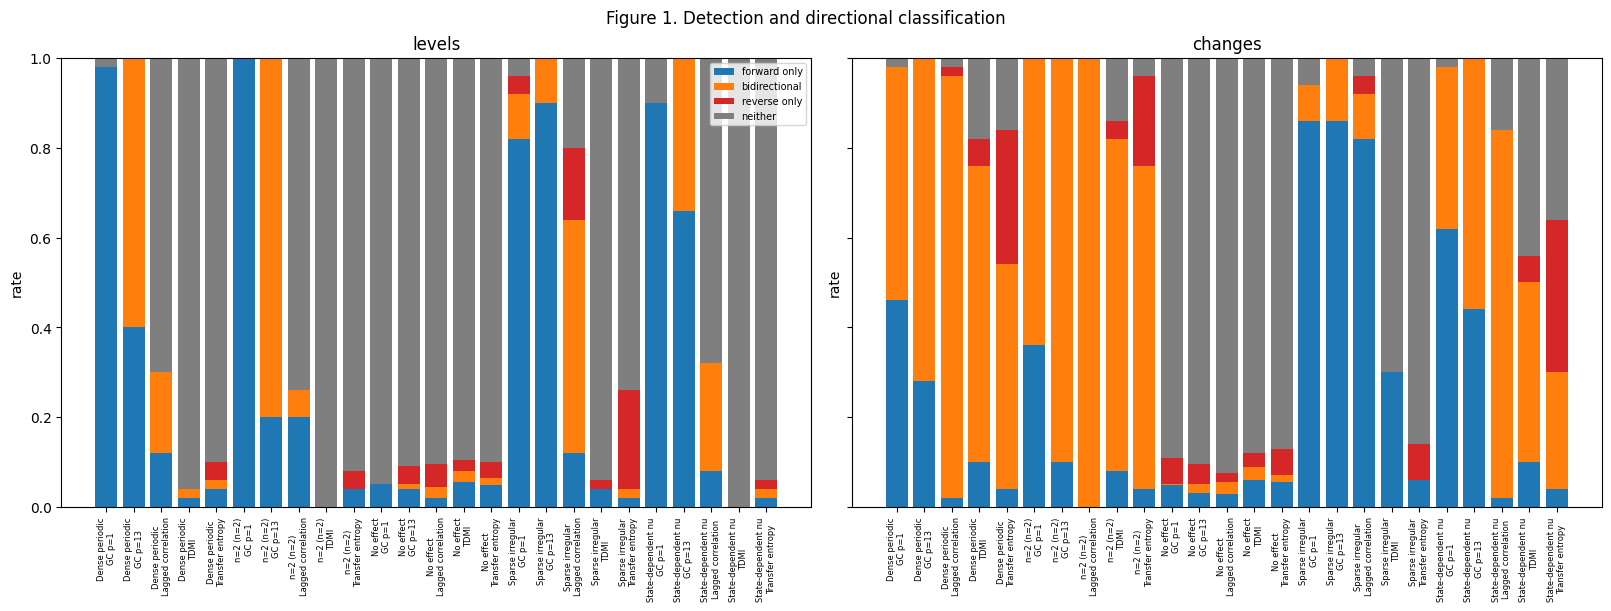

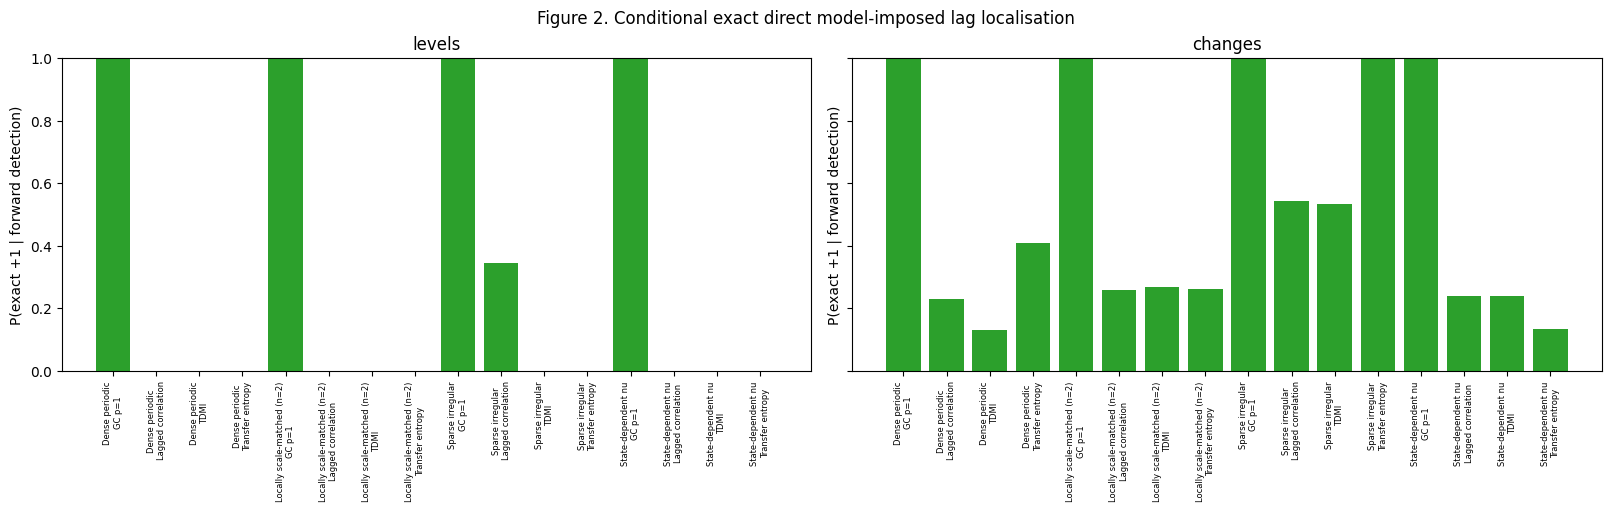

For Granger causality with p=1, rejection is **GC predictive evidence at the pre-specified +1 lag**, not data-driven recovery or discovery of lag +1. GC with p=13 is a joint direct-window predictive test and does not identify a unique lag. Correlation is signed but non-directional; TDMI is non-negative and non-directional; TE is directional conditional information transfer.

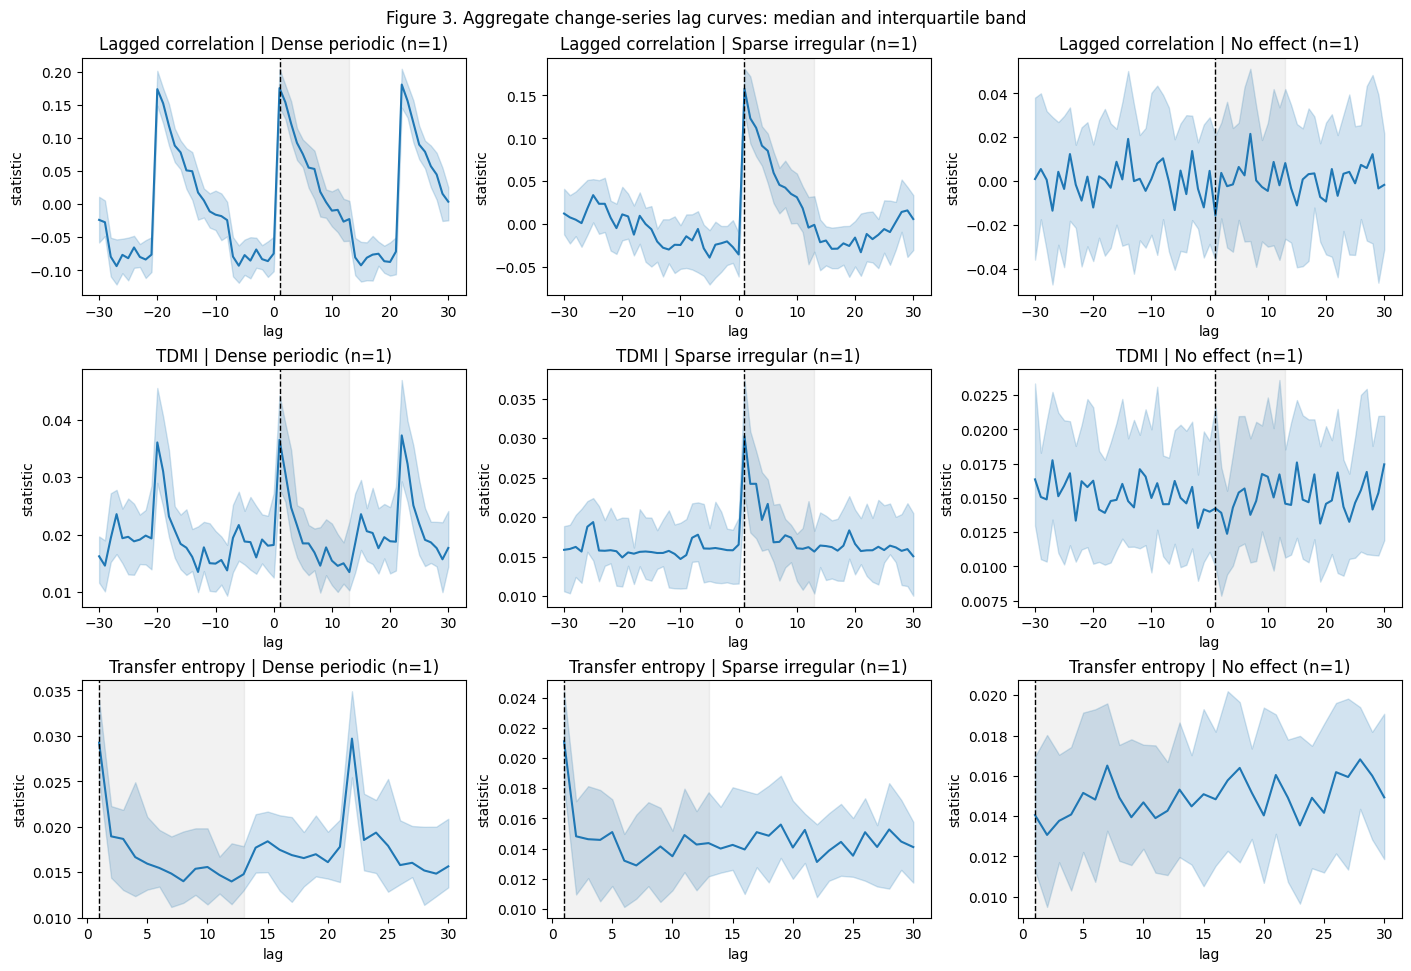

In [10]:
def wilson_interval(successes, total, alpha=.05):
    if total == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(1 - alpha / 2)
    p = successes / total
    denominator = 1 + z ** 2 / total
    centre = (p + z ** 2 / (2 * total)) / denominator
    radius = z * np.sqrt(p * (1 - p) / total + z ** 2 / (4 * total ** 2)) / denominator
    return float(centre - radius), float(centre + radius)


for column in ['forward_detected', 'reverse_detected', 'direct_window_recovery']:
    run_metrics[column] = run_metrics[column].astype('boolean').fillna(False).astype(bool)
run_metrics['exact_plus_1_recovery'] = pd.to_numeric(run_metrics['exact_plus_1_recovery'], errors='coerce')
run_metrics['is_held_out_null'] = run_metrics.case_name.eq('No effect (n=1)') & run_metrics.seed.isin(NULL_EVALUATION_SEEDS)
reporting_metrics = run_metrics.loc[~run_metrics.case_name.eq('No effect (n=1)') | run_metrics.seed.isin(NULL_EVALUATION_SEEDS)].copy()

direction_rows = []
for keys, group in reporting_metrics.groupby(['case_name', 'method', 'transformation']):
    case_name, method, transformation = keys
    total = len(group)
    record = {'case': case_name, 'method': method, 'transformation': transformation, 'runs': total}
    for name, values in [('forward detection', group.forward_detected), ('reverse detection', group.reverse_detected), ('forward only', group.directional_classification.eq('forward only')), ('bidirectional', group.directional_classification.eq('bidirectional')), ('reverse only', group.directional_classification.eq('reverse only')), ('neither', group.directional_classification.eq('neither'))]:
        successes = int(values.sum())
        lo, hi = wilson_interval(successes, total)
        record[name + ' rate'] = successes / total
        record[name + ' 95% CI low'] = lo
        record[name + ' 95% CI high'] = hi
    direction_rows.append(record)
dependence_direction_table = pd.DataFrame(direction_rows)
signal_direction_table = dependence_direction_table.loc[~dependence_direction_table.case.eq('No effect (n=1)')].copy()
display(dependence_direction_table)

signal_metrics = run_metrics.loc[~run_metrics.case_name.eq('No effect (n=1)')].copy()
lag_rows = []
for keys, group in signal_metrics.groupby(['case_name', 'method', 'transformation']):
    forward = group.loc[group.forward_detected]
    lag_rows.append({
        'case': keys[0], 'method': keys[1], 'transformation': keys[2], 'runs': len(group),
        'exact +1 recovery rate': group.exact_plus_1_recovery.mean(),
        'exact +1 conditional on forward detection': forward.exact_plus_1_recovery.mean() if len(forward) else np.nan,
        'direct-window recovery rate': group.direct_window_recovery.mean(),
        'direct-window conditional on forward detection': forward.direct_window_recovery.mean() if len(forward) else np.nan,
        'outside-direct-window peak rate': group.outside_direct_window_peak.astype(float).mean(),
    })
lag_recovery_table = pd.DataFrame(lag_rows)
lag_recovery_display = lag_recovery_table.copy()
display_columns = ['exact +1 recovery rate', 'exact +1 conditional on forward detection']
lag_recovery_display[display_columns] = lag_recovery_display[display_columns].astype(object)
gc13_display_mask = lag_recovery_display.method.eq('Granger causality p=13')
lag_recovery_display.loc[gc13_display_mask, 'exact +1 recovery rate'] = 'Not applicable - joint window test'
lag_recovery_display.loc[gc13_display_mask, 'exact +1 conditional on forward detection'] = 'Not applicable - joint window test'
lag_recovery_table['forward-detection denominator'] = [int(signal_metrics.loc[(signal_metrics.case_name.eq(row['case'])) & (signal_metrics.method.eq(row['method'])) & (signal_metrics.transformation.eq(row['transformation'])) & signal_metrics.forward_detected].shape[0]) for _, row in lag_recovery_table.iterrows()]
assert all(row['forward-detection denominator'] == int(signal_metrics.loc[(signal_metrics.case_name.eq(row['case'])) & (signal_metrics.method.eq(row['method'])) & (signal_metrics.transformation.eq(row['transformation'])) & signal_metrics.forward_detected].shape[0]) for _, row in lag_recovery_table.iterrows())
display(lag_recovery_display)

null_rows = []
for keys, group in run_metrics.loc[run_metrics.is_held_out_null].groupby(['method', 'transformation']):
    null_rows.append({'method': keys[0], 'transformation': keys[1], 'held-out runs': len(group), 'forward false-positive rate': group.forward_detected.mean(), 'reverse false-positive rate': group.reverse_detected.mean(), 'bidirectional false-positive rate': group.directional_classification.eq('bidirectional').mean()})
held_out_null_table = pd.DataFrame(null_rows)
display(held_out_null_table)
display(held_out_fpr_table)

methods_in_results = list(dependence_direction_table.method.drop_duplicates())
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, constrained_layout=True)
for ax, transformation in zip(axes, ['levels', 'changes']):
    subset = dependence_direction_table.loc[dependence_direction_table.transformation.eq(transformation)].copy()
    labels = [row['case'].replace(' (n=1)', '').replace('Locally scale-matched ', 'n=2 ') + '\n' + row['method'].replace('Granger causality ', 'GC ') for _, row in subset.iterrows()]
    bottom = np.zeros(len(subset))
    for column, color in [('forward only rate', 'tab:blue'), ('bidirectional rate', 'tab:orange'), ('reverse only rate', 'tab:red'), ('neither rate', 'tab:gray')]:
        ax.bar(np.arange(len(subset)), subset[column], bottom=bottom, label=column.replace(' rate', ''), color=color)
        bottom += subset[column].to_numpy()
    ax.set(title=transformation, xticks=np.arange(len(subset)), xticklabels=labels, ylim=(0, 1), ylabel='rate')
    ax.tick_params(axis='x', labelrotation=90, labelsize=6)
axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('Figure 1. Detection and directional classification')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, constrained_layout=True)
for ax, transformation in zip(axes, ['levels', 'changes']):
    subset = lag_recovery_table.loc[lag_recovery_table.transformation.eq(transformation) & lag_recovery_table.method.isin(['Lagged correlation', 'Granger causality p=1', 'TDMI', 'Transfer entropy'])]
    labels = [row['case'].replace(' (n=1)', '') + '\n' + row['method'].replace('Granger causality ', 'GC ') for _, row in subset.iterrows()]
    ax.bar(np.arange(len(subset)), subset['exact +1 conditional on forward detection'], color='tab:green')
    ax.set(title=transformation, xticks=np.arange(len(subset)), xticklabels=labels, ylim=(0, 1), ylabel='P(exact +1 | forward detection)')
    ax.tick_params(axis='x', labelrotation=90, labelsize=6)
fig.suptitle('Figure 2. Conditional exact direct model-imposed lag localisation')
plt.show()
display(Markdown('For Granger causality with p=1, rejection is **GC predictive evidence at the pre-specified +1 lag**, not data-driven recovery or discovery of lag +1. GC with p=13 is a joint direct-window predictive test and does not identify a unique lag. Correlation is signed but non-directional; TDMI is non-negative and non-directional; TE is directional conditional information transfer.'))

curve_methods = ['Lagged correlation', 'TDMI'] + (['Transfer entropy'] if TE_VALIDATION_PASSED else [])
curve_cases = ['Dense periodic (n=1)', 'Sparse irregular (n=1)', 'No effect (n=1)']
fig, axes = plt.subplots(len(curve_methods), len(curve_cases), figsize=(14, 3.2 * len(curve_methods)), constrained_layout=True, squeeze=False)
for row_index, method in enumerate(curve_methods):
    for column_index, case_name in enumerate(curve_cases):
        ax = axes[row_index, column_index]
        subset = lag_curves.loc[(lag_curves.method.eq(method)) & (lag_curves.case_name.eq(case_name)) & (lag_curves.transformation.eq('changes'))]
        if method == 'Transfer entropy':
            subset = subset.loc[subset.direction.eq('forward')]
        summary = subset.groupby('lag').statistic.agg(['median', lambda x: x.quantile(.25), lambda x: x.quantile(.75)]).reset_index()
        ax.plot(summary.lag, summary['median'], color='tab:blue')
        ax.fill_between(summary.lag, summary['<lambda_0>'], summary['<lambda_1>'], color='tab:blue', alpha=.2)
        ax.axvline(1, color='black', linestyle='--', linewidth=1)
        ax.axvspan(1, 13, color='grey', alpha=.10)
        ax.set(title=method + ' | ' + case_name, xlabel='lag', ylabel='statistic')
fig.suptitle('Figure 3. Aggregate change-series lag curves: median and interquartile band')
plt.show()

## Final empirical comparison and conclusions

The matrix reports observed repeated-run summaries rather than an overall causality score. Its conclusion is generated from the saved repeated results.

In [11]:
def average_rate(table, method, column, case_name=None, transformation='changes'):
    subset = table.loc[(table.method.eq(method)) & (table.transformation.eq(transformation))]
    if case_name is not None:
        subset = subset.loc[subset.case.eq(case_name)]
    return float(subset[column].mean()) if len(subset) else np.nan


def null_rate(method, column, transformation='changes'):
    subset = held_out_null_table.loc[(held_out_null_table.method.eq(method)) & (held_out_null_table.transformation.eq(transformation))]
    return float(subset[column].iloc[0]) if len(subset) else np.nan


base_methods = ['Lagged correlation', 'Granger causality p=1', 'Granger causality p=13', 'TDMI']
matrix_rows = []
for method in base_methods + ['Transfer entropy']:
    if method == 'Transfer entropy' and not TE_VALIDATION_PASSED:
        matrix_rows.append({'method': method, 'forward dependence detection': 'excluded: TE validation gate failed', 'directional discrimination': 'excluded', 'exact lag recovery': 'excluded', 'conditional direct-window localisation': 'excluded', 'nonlinear robustness': 'excluded', 'sparse-event robustness': 'excluded', 'held-out null control': 'excluded', 'computational cost': 'not run', 'main limitation': 'validation gate failed'})
        continue
    cost = run_metrics.loc[run_metrics.method.eq(method), 'runtime_seconds'].median()
    matrix_rows.append({
        'method': method,
        'forward dependence detection': 'mean non-null change rate ' + format(average_rate(signal_direction_table, method, 'forward detection rate'), '.1%'),
        'directional discrimination': 'mean non-null forward-only change rate ' + format(average_rate(signal_direction_table, method, 'forward only rate'), '.1%'),
        'exact lag recovery': 'not applicable; joint lags 1-13 test' if method == 'Granger causality p=13' else 'mean non-null change P(exact +1 | forward detection) ' + format(average_rate(lag_recovery_table, method, 'exact +1 conditional on forward detection'), '.1%'),
        'conditional direct-window localisation': 'mean non-null change P(lag in +1,...,+13 | forward detection) ' + format(average_rate(lag_recovery_table, method, 'direct-window conditional on forward detection'), '.1%'),
        'nonlinear robustness': 'state-dependent nu change forward rate ' + format(average_rate(signal_direction_table, method, 'forward detection rate', 'State-dependent nu (n=1)'), '.1%'),
        'sparse-event robustness': 'sparse change forward rate ' + format(average_rate(signal_direction_table, method, 'forward detection rate', 'Sparse irregular (n=1)'), '.1%'),
        'held-out null control': 'change forward FPR ' + format(null_rate(method, 'forward false-positive rate'), '.1%'),
        'computational cost': 'median ' + format(float(cost), '.4f') + ' s per run-row',
        'main limitation': 'joint predictive test' if method.startswith('Granger') else 'empirical null threshold; descriptive lag peak',
    })
final_method_comparison = pd.DataFrame(matrix_rows)
display(final_method_comparison)

methods_for_conclusion = ['Lagged correlation', 'Granger causality p=1', 'TDMI'] + (['Transfer entropy'] if TE_VALIDATION_PASSED else [])
change_exact = lag_recovery_table.loc[lag_recovery_table.transformation.eq('changes') & lag_recovery_table.method.isin(methods_for_conclusion), 'exact +1 conditional on forward detection'].mean()
level_exact = lag_recovery_table.loc[lag_recovery_table.transformation.eq('levels') & lag_recovery_table.method.isin(methods_for_conclusion), 'exact +1 conditional on forward detection'].mean()
change_detection = signal_direction_table.loc[signal_direction_table.transformation.eq('changes') & signal_direction_table.method.isin(methods_for_conclusion), 'forward detection rate'].mean()
level_detection = signal_direction_table.loc[signal_direction_table.transformation.eq('levels') & signal_direction_table.method.isin(methods_for_conclusion), 'forward detection rate'].mean()
dense_ambiguity = dependence_direction_table.loc[(dependence_direction_table.case.eq('Dense periodic (n=1)')) & dependence_direction_table.transformation.eq('changes'), ['bidirectional rate', 'reverse only rate']].sum(axis=1).mean()
sparse_ambiguity = dependence_direction_table.loc[(dependence_direction_table.case.eq('Sparse irregular (n=1)')) & dependence_direction_table.transformation.eq('changes'), ['bidirectional rate', 'reverse only rate']].sum(axis=1).mean()
n2_ambiguity = dependence_direction_table.loc[(dependence_direction_table.case.eq('Locally scale-matched (n=2)')) & dependence_direction_table.transformation.eq('changes'), ['bidirectional rate', 'reverse only rate']].sum(axis=1).mean()
sparse_detection = dependence_direction_table.loc[(dependence_direction_table.case.eq('Sparse irregular (n=1)')) & dependence_direction_table.transformation.eq('changes'), 'forward detection rate'].mean()
nonlinear_gc = average_rate(dependence_direction_table, 'Granger causality p=1', 'forward detection rate', 'State-dependent nu (n=1)')
nonlinear_information = np.nanmean([average_rate(dependence_direction_table, method, 'forward detection rate', 'State-dependent nu (n=1)') for method in ['TDMI'] + (['Transfer entropy'] if TE_VALIDATION_PASSED else [])])
null_forward = held_out_null_table['forward false-positive rate'].mean()
null_reverse = held_out_null_table['reverse false-positive rate'].mean()
tdmi_null_rates = held_out_null_table.loc[held_out_null_table.method.eq('TDMI'), ['forward false-positive rate', 'reverse false-positive rate']].to_numpy(dtype=float).ravel()
te_signal_detection = average_rate(signal_direction_table, 'Transfer entropy', 'forward detection rate') if TE_VALIDATION_PASSED else np.nan
completed_pairs = signal_metrics[['case_name', 'seed']].drop_duplicates().shape[0]
conclusion = '## Final conclusions\n\n'
conclusion += 'Across the non-null cases, mean forward detection is ' + format(change_detection, '.1%') + ' for changes and ' + format(level_detection, '.1%') + ' for levels, whereas mean conditional exact +1 localisation P(estimated lag = +1 | forward detection) is ' + format(change_exact, '.1%') + ' and ' + format(level_exact, '.1%') + ', respectively. Dependence detection is therefore easier than exact-lag localisation; changes locate +1 more often in this repeated design.\n\n'
conclusion += 'For change-series directional classifications, dense periodic ambiguity (bidirectional plus reverse-only) averages ' + format(dense_ambiguity, '.1%') + ', versus ' + format(sparse_ambiguity, '.1%') + ' for sparse irregular and ' + format(n2_ambiguity, '.1%') + ' for locally matched n=2. Sparse irregular change forward detection averages ' + format(sparse_detection, '.1%') + '. The state-dependent nu case has p=1 GC change forward detection of ' + format(nonlinear_gc, '.1%') + ' versus ' + format(nonlinear_information, '.1%') + ' for the available information-theoretic methods.\n\n'
conclusion += 'Held-out no-effect rates vary across methods: mean forward and reverse false-positive rates are ' + format(null_forward, '.1%') + ' and ' + format(null_reverse, '.1%') + ', while TDMI spans ' + format(np.nanmin(tdmi_null_rates), '.1%') + ' to ' + format(np.nanmax(tdmi_null_rates), '.1%') + ' across levels and changes under the dedicated disjoint 250-calibration/250-evaluation design. TE validation ' + ('passed, but its mean non-null change forward detection is the weaker ' + format(te_signal_detection, '.1%') + '.' if TE_VALIDATION_PASSED else 'failed, so TE was excluded automatically.') + ' The retained signal experiment completed ' + str(completed_pairs) + ' reported case-seed pairs with ' + str(len(failures)) + ' recorded signal failures. These are one-model synthetic predictive and dependence diagnostics; none establishes interventionist or physical causality.'
display(Markdown(conclusion))

,method,forward dependence detection,directional discrimination,exact lag recovery,conditional direct-window localisation,nonlinear robustness,sparse-event robustness,held-out null control,computational cost,main limitation
0,Lagged correlation,mean non-null change rate 93.0%,mean non-null forward-only change rate 21.5%,mean non-null change P(exact +1 | forward dete...,"mean non-null change P(lag in +1,...,+13 | for...",state-dependent nu change forward rate 84.0%,sparse change forward rate 92.0%,change forward FPR 5.6%,median 0.0029 s per run-row,empirical null threshold; descriptive lag peak
1,Granger causality p=1,mean non-null change rate 97.5%,mean non-null forward-only change rate 57.5%,mean non-null change P(exact +1 | forward dete...,"mean non-null change P(lag in +1,...,+13 | for...",state-dependent nu change forward rate 98.0%,sparse change forward rate 94.0%,change forward FPR 5.2%,median 0.0021 s per run-row,joint predictive test
2,Granger causality p=13,mean non-null change rate 100.0%,mean non-null forward-only change rate 42.0%,not applicable; joint lags 1-13 test,"mean non-null change P(lag in +1,...,+13 | for...",state-dependent nu change forward rate 100.0%,sparse change forward rate 100.0%,change forward FPR 5.2%,median 0.0068 s per run-row,joint predictive test
3,TDMI,mean non-null change rate 59.5%,mean non-null forward-only change rate 14.5%,mean non-null change P(exact +1 | forward dete...,"mean non-null change P(lag in +1,...,+13 | for...",state-dependent nu change forward rate 50.0%,sparse change forward rate 30.0%,change forward FPR 8.8%,median 0.1173 s per run-row,empirical null threshold; descriptive lag peak
4,Transfer entropy,mean non-null change rate 41.5%,mean non-null forward-only change rate 4.5%,mean non-null change P(exact +1 | forward dete...,"mean non-null change P(lag in +1,...,+13 | for...",state-dependent nu change forward rate 30.0%,sparse change forward rate 6.0%,change forward FPR 7.2%,median 0.0044 s per run-row,empirical null threshold; descriptive lag peak


## Final conclusions

Across the non-null cases, mean forward detection is 72.9% for changes and 34.9% for levels, whereas mean conditional exact +1 localisation P(estimated lag = +1 | forward detection) is 51.5% and 31.0%, respectively. Dependence detection is therefore easier than exact-lag localisation; changes locate +1 more often in this repeated design.

For change-series directional classifications, dense periodic ambiguity (bidirectional plus reverse-only) averages 74.4%, versus 8.8% for sparse irregular and 84.8% for locally matched n=2. Sparse irregular change forward detection averages 64.4%. The state-dependent nu case has p=1 GC change forward detection of 98.0% versus 40.0% for the available information-theoretic methods.

Held-out no-effect rates vary across methods: mean forward and reverse false-positive rates are 6.1% and 5.3%, while TDMI spans 4.8% to 8.8% across levels and changes under the dedicated disjoint 250-calibration/250-evaluation design. TE validation passed, but its mean non-null change forward detection is the weaker 41.5%. The retained signal experiment completed 200 reported case-seed pairs with 0 recorded signal failures. These are one-model synthetic predictive and dependence diagnostics; none establishes interventionist or physical causality.